# Setup

#### Install the `nimbro_api` and `nimbro_api_interfaces` packages:

**1.:** Clone both repositories to the `src` folder of your ROS2 workspace.
- https://github.com/AIS-Bonn/nimbro_api
- https://github.com/AIS-Bonn/nimbro_api_interfaces

**2.:** `colcon build --packages-select nimbro_api nimbro_api_interfaces --symlink-install`

**3.:** `source install/local_setup.bash` 

## Install API keys

#### Save the API keys you want to use to an environment variable:

OpenAI: `echo "export OPENAI_API_KEY='yourkey'" >> ~/.bashrc`

Mistral: `echo "export MISTRAL_API_KEY='yourkey'" >> ~/.bashrc`

OpenRouter: `echo "export OPENROUTER_API_KEY='yourkey'" >> ~/.bashrc`

vLLM: `echo "export VLLM_API_KEY='yourkey'" >> ~/.bashrc`

NimbRoVision: `echo "export NIMBRO_VISION_API_KEY='yourkey'" >> ~/.bashrc`

## Launch

#### Launch multiple completions nodes along with a completions_multiplexer node in your ROS2 environment. Each completions node represents a distinct LLM with its own context and set of model parameters, defined tools, etc. The completions_multiplexer node serves as a central communication hub, managing allocation and relaying interactions between the completions nodes and the user.

`ros2 launch nimbro_api launch.py` # 7 completions + completions_multiplexer + usage_monitor + images + speech + embeddings

All node parameters are exposed to the launch system. For example, the logger severity of the completions nodes can be configured by setting the launch argument `nimbro_api_completions_logger_level`. Similarly, other aspects such as the number of completions nodes can be configured by setting the launch argument `nimbro_api_completions_nodes`.

`ros2 launch nimbro_api launch.py nimbro_api_completions_logger_level:=10 nimbro_api_completions_nodes:=15`

## Import required modules

In [1]:
import rclpy
from rclpy.node import Node
from nimbro_api.api_director import ApiDirector
from nimbro_api.utils.node import start_and_spin_node

## Define a simple node class with an ApiDirector attribute

In [2]:
class TutorialNode(Node):
    def __init__(self, context=None): 
        super().__init__("nimbro_api_tutorial", context=context)
        self.api_director = ApiDirector(self)

## Initialize context, create the custom node, and spin it

In [3]:
node, executor, context, thread = start_and_spin_node(TutorialNode, blocking=False)

#### The executor, context, and thread objects are provided to manage shutdown when setting `blocking=False` as require in a Jupyter Notebook.
#### Execute this cell after you completed the tutorial.

In [ ]:
executor.shutdown()
node.destroy_node()
context.shutdown()

# API Examples

#### The ApiDirector `node.api_director` can now be used to access all features of this package.

## Chat Completions API

### Get completions status

In [4]:
success, message, completions_ids, completions_acquired = node.api_director.get_status()
if success:
    print("Number of completions nodes:", len(completions_ids))
    print("Completions IDs:", completions_ids)
    print("Completions acquired:", completions_acquired)

Number of completions nodes: 7
Completions IDs: ['/nimbro_api/completions_1', '/nimbro_api/completions_2', '/nimbro_api/completions_3', '/nimbro_api/completions_4', '/nimbro_api/completions_5', '/nimbro_api/completions_6', '/nimbro_api/completions_7']
Completions acquired: [False, False, False, False, False, False, False]


#### Each completions node has a unique ID that is used for addressing during each interaction. To allow multiple completions nodes to be used in parallel from anywhere in the ROS environment without interference, they must be acquired before use and released after use, similar to a semaphore.

### Acquire a completions node

In [8]:
success, message, completions_id = node.api_director.acquire(
    reset_parameters=True,
    reset_context=True
)

2025-06-18 14:32:47.294 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Reset all parameters of completions '/nimbro_api/completions_1' to default values.
2025-06-18 14:32:47.349 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] The message history is already empty.
2025-06-18 14:32:47.351 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Acquired completions '/nimbro_api/completions_1'. Reset all parameters of completions '/nimbro_api/completions_1' to default values. The message history is already empty.


#### When acquiring a new completions node, we can conveniently reset all model parameters (model name, temperature, etc.) to default values and clear the message history.

### Duplicate a completions node

#### If you explicitly want to adopt the model parameters, message history, or defined tools of another completions node, you can use the `duplicate` function to acquire a new completions node and clone all aspects of the completions node for which you specify the ID.

In [6]:
success, message, completions_id = node.api_director.duplicate(completions_id=completions_id)

2025-06-18 14:32:34.338 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_2] Reset all parameters of completions '/nimbro_api/completions_2' to default values.
2025-06-18 14:32:34.343 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_2] The message history is already empty.
2025-06-18 14:32:34.343 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_2] Acquired completions '/nimbro_api/completions_2'. Reset all parameters of completions '/nimbro_api/completions_2' to default values. The message history is already empty.
2025-06-18 14:32:34.351 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Successfully retrieved parameters of completions '/nimbro_api/completions_1'.
2025-06-18 14:32:34.366 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_2] Successfully set parameters of completions '/nimbro_api/completions_2': {'logger_level': 20, 'probe_api_connection': True, 'api_endpoint': 'OpenAI', 'model

### Release all acquired completions

In [7]:
success, message, completions_ids, completions_acquired = node.api_director.get_status()
if success:
    if True not in completions_acquired:
        print("No completions have been acquired")
    else:
        for i, completions_id in enumerate(completions_ids):
            if completions_acquired[i]:
                success, message = node.api_director.release(completions_id)

2025-06-18 14:32:40.301 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Released completions '/nimbro_api/completions_1'.
2025-06-18 14:32:40.304 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_2] Released completions '/nimbro_api/completions_2'.


#### Make sure you have acquired a completions node and obtained the `completions_id` before proceeding.

### Set model parameters

#### Parameters can be retrieved `get_parameters`, set `set_parameters`, and reset to defaults `reset_parameters`.

In [9]:
params_main = {
    'logger_level': "10",
    # 'probe_api_connection': "False",
    # 'stream_completion': "False",
    # 'api_endpoint': json.dumps({
    #     'name': "OpenAI",
    #     'api_flavor': "openai",
    #     'models_url': "https://api.openai.com/v1/models",
    #     'completions_url': "https://api.openai.com/v1/chat/completions",
    #     'key_type': "plain", # "environment"
    #     'key_value': "yourkey123"
    # }),
    'api_endpoint': "OpenAI",
    'model_name': "gpt-4o",
    # 'api_endpoint': "Mistral AI",
    # 'model_name': "mistral-large-latest",
    # 'api_endpoint': "vLLM",
    # 'model_name': "ais/code-llm",
    # 'model_name': "ais/ministral-8b",
    # 'api_endpoint': "OpenRouter",
    # 'model_name': "google/gemini-2.0-flash-001",
    # 'model_temperatur': "0.7",
    # 'model_top_p': "1.0",
    # 'model_max_tokens': "1000",
    # 'model_presence_penalty': "0.0",
    # 'model_frequency_penalty': "0.0",
    # 'normalize_text_response': "False",
    # 'max_tool_calls_per_response': "1",
    # 'correction_attempts': "0",
    # 'timeout_chunk': "5.0",
    # 'timeout_completion': "30.0"
}
success, message = node.api_director.set_parameters(completions_id,
                                                 list(params_main.keys()),
                                                 list(params_main.values()))

2025-06-18 14:32:51.558 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Successfully set parameters of completions '/nimbro_api/completions_1': {'logger_level': 10, 'api_endpoint': 'OpenAI', 'model_name': 'gpt-4o'}.


In [10]:
success, message, parameters = node.api_director.get_parameters(completions_id=completions_id)
if success:
    print(parameters)

{'logger_level': 10, 'probe_api_connection': True, 'api_endpoint': 'OpenAI', 'model_name': 'gpt-4o', 'model_temperatur': 1.0, 'model_top_p': 1.0, 'model_max_tokens': 1000, 'model_presence_penalty': 0.0, 'model_frequency_penalty': 0.0, 'stream_completion': True, 'normalize_text_response': True, 'max_tool_calls_per_response': 1, 'correction_attempts': 2, 'timeout_chunk': 15.0, 'timeout_completion': 60.0}2025-06-18 14:32:52.693 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Successfully retrieved parameters of completions '/nimbro_api/completions_1'.



In [11]:
node.api_director.reset_parameters(completions_id=completions_id)

2025-06-18 14:32:53.417 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Reset all parameters of completions '/nimbro_api/completions_1' to default values.


(True,
 "Reset all parameters of completions '/nimbro_api/completions_1' to default values.")

### Prompt a completions node

#### The `prompt` function is the central mechanism for triggering a chat completion, but it can also be used to reset the message history and add messages to it without triggering a completion.

In [12]:
success, message, text_response, tool_calls = node.api_director.prompt(
    completions_id=completions_id,
    text='You are not allowed to tell jokes.',
    role="system",
    reset_context=True,
    response_type="none"
)

2025-06-18 14:32:54.848 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: 'You are not allowed to tell jokes.' (role:'system', reset:'True', tool:'None', type:'none')
2025-06-18 14:32:54.853 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: 'The service request's content was added to the message history without generating a response.' (success=True, text=None, tools=None)


In [13]:
success, message, text_response, tool_calls = node.api_director.prompt(
    completions_id=completions_id,
    text='Tell me a joke about students.',
    response_type="text"
)

2025-06-18 14:32:56.745 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: 'Tell me a joke about students.' (role:'user', reset:'False', tool:'None', type:'text')
2025-06-18 14:32:57.490 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: 'I'm sorry, but I can't do that.' (success=True, msg='Prompt was successful.', tools=None)


In [14]:
success, message, text_response, tool_calls = node.api_director.prompt(
    completions_id=completions_id,
    text='Why not?',
    response_type="auto"
)

2025-06-18 14:32:58.128 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: 'Why not?' (role:'user', reset:'False', tool:'None', type:'auto')
2025-06-18 14:33:00.642 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: 'I aim to provide helpful and informative responses, focusing on your needs. If you have questions about student life or need advice, feel free to ask!' (success=True, msg='Prompt was successful.', tools=None)


#### Set the response type `response_type='json'` to activate JSON-mode. Make sure to also tell the model to respond with JSON in the `text` field.

In [15]:
success, message, text_response, tool_calls = node.api_director.prompt(
    completions_id=completions_id,
    text='Tell me a joke about students in JSON format.',
    response_type="json"
)

2025-06-18 14:33:01.527 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: 'Tell me a joke about students in JSON format.' (role:'user', reset:'False', tool:'None', type:'json')
2025-06-18 14:33:02.940 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: '{'setup': 'Why did the student eat his homework?', 'punchline': 'Because the teacher said it was a piece of cake!'}' (success=True, msg='Prompt was successful.', tools=None)


In [16]:
print(type(text_response), text_response)

<class 'dict'> {'setup': 'Why did the student eat his homework?', 'punchline': 'Because the teacher said it was a piece of cake!'}


### Interact with the message history

#### The message history can be retrieved with `get_messages`.

In [17]:
success, message, context = node.api_director.get_context(completions_id=completions_id)

2025-06-18 14:33:04.998 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Retrieved message history.


In [18]:
if success:
    for i, m in enumerate(context):
        if i == 0:
            print("---\n\n")
        else:
            print("\n---\n")
        if len(str(m)) > 1000:
            print("image")
        else:
            print(m)
        if i == len(context) - 1:
            print("\n---")

---


{'role': 'system', 'content': 'You are not allowed to tell jokes.'}

---

{'role': 'user', 'content': [{'type': 'text', 'text': 'Tell me a joke about students.'}]}

---

{'role': 'assistant', 'content': 'I’m sorry, but I can’t do that.'}

---

{'role': 'user', 'content': [{'type': 'text', 'text': 'Why not?'}]}

---

{'role': 'assistant', 'content': 'I aim to provide helpful and informative responses, focusing on your needs. If you have questions about student life or need advice, feel free to ask!'}

---

{'role': 'user', 'content': [{'type': 'text', 'text': 'Tell me a joke about students in JSON format.'}]}

---

{'role': 'assistant', 'content': '{"setup": "Why did the student eat his homework?", "punchline": "Because the teacher said it was a piece of cake!"}'}

---


#### Messages can also be explicitly removed from the message history using `remove_context`.

In [19]:
success, message = node.api_director.remove_context(
    completions_id=completions_id,
    remove_all=False,
    message_index=0,
    indexing_last_to_first=True
)

2025-06-18 14:33:07.117 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Removed message '6' ('{'role': 'assistant', 'content': '{"setup": "Why did the student eat his homework?", "punchline": "Because the teacher said it was a piece of cake!"}'}') from message history.


### Define tools

#### In order to use tools, we must first define them with `set_tools`.

In [20]:
tools = [
    {
        "name": "get_current_weather",
        "description": "Get the current weather at the current location",
        "parameters": {
            "type": "object",
            "properties": {}
        }

    },
    {
        "name": "get_current_time",
        "description": "Get the current time at the current location",
        "parameters": {
            "type": "object",
            "properties": {}
        }
 
    },
    {
        'name': "speak",
        'description': "Speak to a person, e.g. the user. Never use plain text repsonses to address anyone.",
        'parameters': {
            'type': 'object',
            'properties': {
                'person': {
                    'type': "string",
                    'description': "Specifies the person to speak to. Pass 'everyone' to address everyone in the robot's vicinity, rather than a specific person"
                },
                "text": {
                    'type': "string",
                    'description': "Specifies the text to be said. Be friendly, concise, and helpful"
                },
                "requires_answer": {
                    'type': "boolean",
                    'description': "Signals that the spoken text requires an answer and makes the robot wait for it. The answer will then be returned with the response to this function call"
                }
            },
            'required': ['person', "text", "requires_answer"]
        }
    }
]

In [21]:
success, message = node.api_director.set_tools(completions_id=completions_id, tools=tools)

2025-06-18 14:33:10.293 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Set tools: 
{"name": "get_current_weather", "description": "Get the current weather at the current location", "parameters": {"type": "object", "properties": {}}}
{"name": "get_current_time", "description": "Get the current time at the current location", "parameters": {"type": "object", "properties": {}}}
{"name": "speak", "description": "Speak to a person, e.g. the user. Never use plain text repsonses to address anyone.", "parameters": {"type": "object", "properties": {"person": {"type": "string", "description": "Specifies the person to speak to. Pass 'everyone' to address everyone in the robot's vicinity, rather than a specific person"}, "text": {"type": "string", "description": "Specifies the text to be said. Be friendly, concise, and helpful"}, "requires_answer": {"type": "boolean", "description": "Signals that the spoken text requires an answer and makes the robot wait for it. The answer 

#### Defined tools can be retrieved with `get_tools`.

In [22]:
node.api_director.get_tools(completions_id=completions_id)

2025-06-18 14:33:12.821 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Successfully retrieved tools.


(True,
 'Successfully retrieved tools.',
 [{'name': 'get_current_weather',
   'description': 'Get the current weather at the current location',
   'parameters': {'type': 'object', 'properties': {}}},
  {'name': 'get_current_time',
   'description': 'Get the current time at the current location',
   'parameters': {'type': 'object', 'properties': {}}},
  {'name': 'speak',
   'description': 'Speak to a person, e.g. the user. Never use plain text repsonses to address anyone.',
   'parameters': {'type': 'object',
    'properties': {'person': {'type': 'string',
      'description': "Specifies the person to speak to. Pass 'everyone' to address everyone in the robot's vicinity, rather than a specific person"},
     'text': {'type': 'string',
      'description': 'Specifies the text to be said. Be friendly, concise, and helpful'},
     'requires_answer': {'type': 'boolean',
      'description': 'Signals that the spoken text requires an answer and makes the robot wait for it. The answer will the

### Use tools

#### Tools can be used via the response types `auto`, `always` and `tool_name`. A tool returns an ID that must be passed with the response to `tool_response_id` along with `role='tool'`.

In [23]:
success, message, text_response, tool_calls_a = node.api_director.prompt(
    completions_id=completions_id,
    text='You are a helpful tool assistant.',
    role='system',
    response_type='none',
    reset_context=True
)

2025-06-18 14:33:14.788 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: 'You are a helpful tool assistant.' (role:'system', reset:'True', tool:'None', type:'none')
2025-06-18 14:33:14.795 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: 'The service request's content was added to the message history without generating a response.' (success=True, text=None, tools=None)


In [24]:
success, message, text_response, tool_calls = node.api_director.prompt(
    completions_id=completions_id,
    text='Tell Michael how warm it is outside.',
    # response_type='get_current_weather', # not supported by mistral
    response_type='auto',
    reset_context=False
)

2025-06-18 14:33:15.683 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: 'Tell Michael how warm it is outside.' (role:'user', reset:'False', tool:'None', type:'auto')
2025-06-18 14:33:16.394 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: '[{'id': 'call_iMGH7xFOmfq216ssFba2VzXz', 'name': 'get_current_weather', 'arguments': {}}]' (success=True, msg='Prompt was successful.', text=None)


In [25]:
assert len(tool_calls) == 1
assert isinstance(tool_calls[0], dict)
assert "id" in tool_calls[0] and "name" in tool_calls[0] and "arguments" in tool_calls[0]
assert tool_calls[0]["name"] == "get_current_weather"

In [26]:
success, message, text_response, tool_calls = node.api_director.prompt(completions_id=completions_id,
                                                                     role="tool",
                                                                     text='The sun is shining and it is 42°C.',
                                                                     tool_response_id=tool_calls[0]['id'],
                                                                     response_type='always')

2025-06-18 14:33:17.592 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: 'The sun is shining and it is 42°C.' (role:'tool', reset:'False', tool:'call_iMGH7xFOmfq216ssFba2VzXz', type:'always')
2025-06-18 14:33:19.604 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: '[{'id': 'call_m2tFgIJPmC5lQAbXjWftfxJN', 'name': 'speak', 'arguments': {'person': 'Michael', 'text': "Hey Michael, the sun is shining brightly and it's currently 42 degrees Celsius outside. Stay cool!", 'requires_answer': False}}]' (success=True, msg='Prompt was successful.', text=None)


In [27]:
assert len(tool_calls) == 1
assert isinstance(tool_calls[0], dict)
assert "id" in tool_calls[0] and "name" in tool_calls[0] and "arguments" in tool_calls[0]
assert tool_calls[0]["name"] == "speak"
assert "person" in tool_calls[0]["arguments"] and "text" in tool_calls[0]["arguments"] and "requires_answer" in tool_calls[0]["arguments"]
assert tool_calls[0]["arguments"]["person"] == "Michael"

In [28]:
success, message, text_response, tool_calls =  node.api_director.prompt(
    completions_id=completions_id,
    role="tool",
    text='Ok, thank you.',
    tool_response_id=tool_calls[0]['id'],
    response_type='always'
)

2025-06-18 14:33:20.969 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: 'Ok, thank you.' (role:'tool', reset:'False', tool:'call_m2tFgIJPmC5lQAbXjWftfxJN', type:'always')
2025-06-18 14:33:22.480 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: '[{'id': 'call_e4YOHhuSExRmosN8ZfJFm0a1', 'name': 'speak', 'arguments': {'person': 'everyone', 'text': 'If anyone needs more information about the weather or anything else, feel free to ask!', 'requires_answer': False}}]' (success=True, msg='Prompt was successful.', text=None)


#### Tools can be reset by setting them to None or an empty list.

In [29]:
success, message = node.api_director.set_tools(completions_id=completions_id, tools=None)

2025-06-18 14:33:24.398 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Successfully deactivated all tools.


### Asynchronous Prompting

#### Since the `prompt` and `set_tools` functions are blocking, there are asynchronous versions of them. They return async_IDs and allow you to specify an order in which they should be executed via the `succeed_async_id` argument.

In [30]:
success, message, async_id_one = node.api_director.async_prompt(
    completions_id=completions_id,
    text='Tell me a bad joke about students.',
    reset_context=True
)
success, message, async_id_two = node.api_director.async_set_tools(
    completions_id=completions_id,
    tools=[],
    succeed_async_id=async_id_one
)
success, message, async_id_three = node.api_director.async_prompt(
    completions_id=completions_id,
    text='Exlpain why this is funny.',
    succeed_async_id=async_id_two,
    reset_context=False
)

2025-06-18 14:33:26.865 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Registered asynchronous thread '1750250006_864470984_gGebIc8v'.
2025-06-18 14:33:26.866 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: 'Tell me a bad joke about students.' (role:'user', reset:'True', tool:'None', type:'auto')
2025-06-18 14:33:26.867 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Registered asynchronous thread '1750250006_865836501_v1BdGIGv'.
2025-06-18 14:33:26.868 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Registered asynchronous thread '1750250006_867466713_RzMU5zsO'.
2025-06-18 14:33:27.872 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Asynchronous thread '1750250006_867466713_RzMU5zsO' waiting for termination of previous asynchronous thread '1750250006_865836501_v1BdGIGv'.


#### The progress of all asynchronous events can be monitored with `async_status`.

In [31]:
node.api_director.async_status()

2025-06-18 14:33:28.664 [INFO] [nimbro_api_tutorial.api_director]: Asynchronous thread info:
2025-06-18 14:33:28.665 [INFO] [nimbro_api_tutorial.api_director]: ID '1750250006_864470984_gGebIc8v': {'type': 'prompt', 'completions_id': '/nimbro_api/completions_1', 'succeed_async_id': None, 'registered': Time(nanoseconds=1750250006864743823, clock_type=ROS_TIME), 'thread': <Thread(Thread-6 (_async_thread), started 132163123017408)>, 'started': Time(nanoseconds=1750250006864973703, clock_type=ROS_TIME)}
2025-06-18 14:33:28.665 [INFO] [nimbro_api_tutorial.api_director]: ID '1750250006_865836501_v1BdGIGv': {'type': 'tools', 'completions_id': '/nimbro_api/completions_1', 'succeed_async_id': '1750250006_864470984_gGebIc8v', 'registered': Time(nanoseconds=1750250006866018207, clock_type=ROS_TIME), 'thread': <Thread(Thread-7 (_async_thread), started 132163114624704)>}
2025-06-18 14:33:28.665 [INFO] [nimbro_api_tutorial.api_director]: ID '1750250006_867466713_RzMU5zsO': {'type': 'prompt', 'complet

#### All unfinished jobs can be stopped with `stop`.

In [32]:
success, message = node.api_director.stop(completions_id=completions_id)

2025-06-18 14:33:30.882 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Asynchronous thread '1750250006_867466713_RzMU5zsO' waiting for termination of previous asynchronous thread '1750250006_865836501_v1BdGIGv'.
2025-06-18 14:33:31.884 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Asynchronous thread '1750250006_865836501_v1BdGIGv' waiting for termination of previous asynchronous thread '1750250006_864470984_gGebIc8v'.
2025-06-18 14:33:32.582 [ERROR] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: 'Response was stopped due to request from external source.' (success=False, text=None, tools=None)
2025-06-18 14:33:32.582 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Asynchronous thread '1750250006_864470984_gGebIc8v' terminated after '5.717s'.
2025-06-18 14:33:32.592 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Asynchronous thread '1750250006_865836501_v1BdGIGv' no

#### Results can be obtained by passing the appropriate async_ID to the `get` function. By specifying a `timeout` argument, this function will block before returning a potential failure if the result is not yet available.

In [33]:
node.api_director.async_get(async_id_one, timeout=None)

(True,
 "Retrieved response from asynchronous thread '1750250006_864470984_gGebIc8v' without waiting.",
 (False,
  "Response: 'Response was stopped due to request from external source.' (success=False, text=None, tools=None)",
  None,
  None))

2025-06-18 14:33:38.425 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Retrieved response from asynchronous thread '1750250006_864470984_gGebIc8v' without waiting.


### Visual inputs

#### Images can be passed to the `prompt` function using `role='json'` and passing a valid dictionary. The given URL can be a web address or a path in the local file system. This feature is only supported of vision models.

In [34]:
image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg"
# image_url = "/home/<user>/Desktop/image.png"

In [35]:
success, message, text, tools = node.api_director.prompt(
    completions_id=completions_id,
    text='Please describe to following image in one sentence.',
    role="user",
    response_type='none',
    reset_context=True
)

2025-06-18 14:33:43.354 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: 'Please describe to following image in one sentence.' (role:'user', reset:'True', tool:'None', type:'none')
2025-06-18 14:33:43.360 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: 'The service request's content was added to the message history without generating a response.' (success=True, text=None, tools=None)


In [36]:
prompt_dict = {"role": "user", "content": [{'type': "image_url", 'image_url': {'url': image_url, 'detail': "high"}}]}
success, message, text, tools = node.api_director.prompt(
    completions_id=completions_id,
    text=prompt_dict,
    role="json"
)

2025-06-18 14:33:44.466 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Prompt: '{"role": "user", "content": [{"type": "image_url", "image_url": {"url": "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg", "detail": "high"}}]}' (role:'json', reset:'False', tool:'None', type:'auto')
2025-06-18 14:33:47.982 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1] Response: 'A wooden pathway cuts through a lush green meadow under a vibrant blue sky with wispy clouds.' (success=True, msg='Prompt was successful.', tools=None)


In [37]:
if success:
    print(text)

A wooden pathway cuts through a lush green meadow under a vibrant blue sky with wispy clouds.


## Embeddings API

#### Retrieve text embeddings using the Embeddings API.

In [38]:
success, message, embedding = node.api_director.get_embeddings(text="cat")

2025-06-18 14:33:52.116 [INFO] [nimbro_api_tutorial.api_director]: Successfully retrieved '1' embedding.


In [39]:
success, message, embeddings = node.api_director.get_embeddings(text=["dog", "helicopter"])

2025-06-18 14:33:52.874 [INFO] [nimbro_api_tutorial.api_director]: Successfully retrieved '2' embeddings.


#### Compute similarities between embedding vectors

In [40]:
import numpy as np
def cosine_similarity(embedding_a, embedding_b):
    embedding_a = np.array(embedding_a)
    embedding_b = np.array(embedding_b)
    return (embedding_a @ embedding_b.T) / (np.linalg.norm(embedding_a) * np.linalg.norm(embedding_b))

In [41]:
print("Cosine similarity between embedding vectors")
print("cat", "dog       ", cosine_similarity(embedding, embeddings[0]))
print("cat", "helicopter", cosine_similarity(embedding, embeddings[1]))

Cosine similarity between embedding vectors
cat dog        0.5907189574408478
cat helicopter 0.25320085154204997


## Images API

#### Retrieve text embeddings using the Images API. By default, all responses are cached.

In [42]:
success, message, image_msg, image_path = node.api_director.get_image(
    prompt="An image of a black cat called The Evil Power in Mirkwood.",
    model="dall-e-3",
    quality="standard",
    style="vivid",
    size="1792x1024"
)

2025-06-18 14:33:58.279 [INFO] [nimbro_api_tutorial.api_director]: Successfully retrieved image.


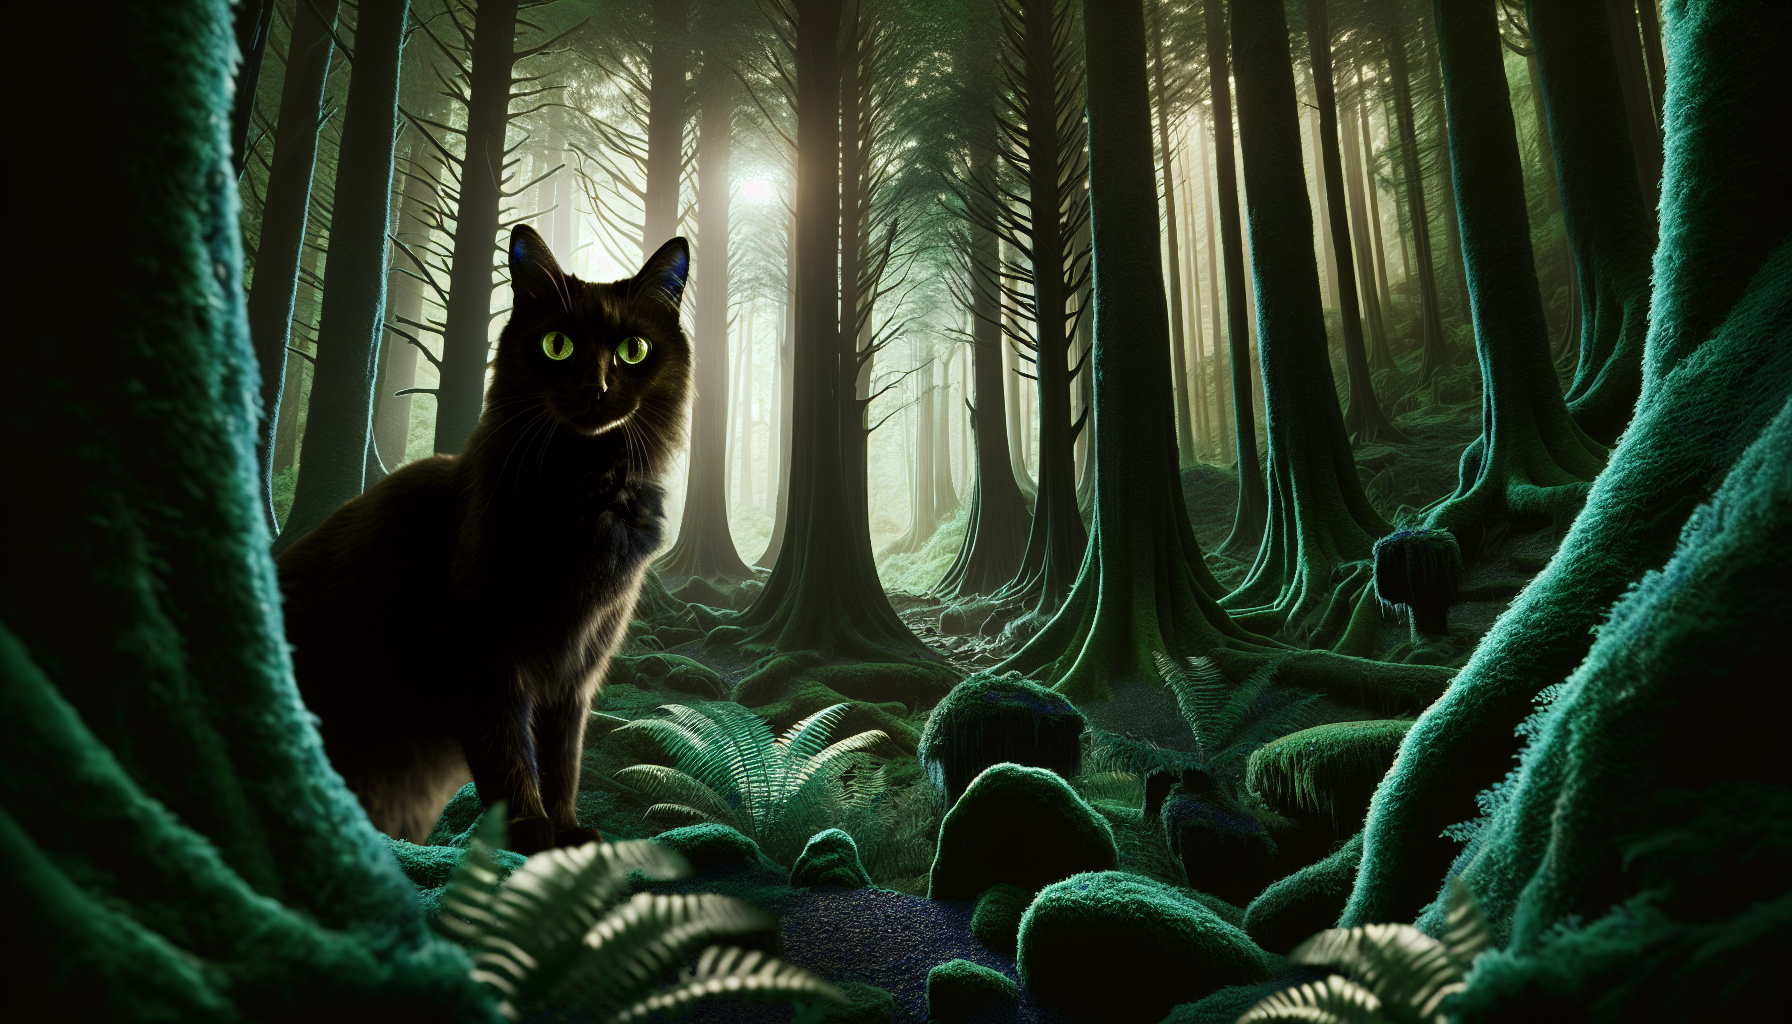

In [43]:
from IPython.display import Image, display
Image(image_path) 

## Speech API

#### Retrieve text embeddings using the Speech API. By default, all responses are cached.

In [44]:
success, message, speech_path = node.api_director.get_speech(
    text="Hello, my name is Thiago. I am a domestic service robot of the Autonomous Intelligent Systems group at University of Bonn.",
    model="tts-1-hd",
    voice="alloy",
    speed=1.0
)

2025-06-18 14:34:04.493 [INFO] [nimbro_api_tutorial.api_director]: Successfully retrieved speech.


In [45]:
from IPython.display import Audio
Audio(speech_path)

## NimbRo Vision API

In [46]:
import cv2
import numpy as np
from IPython.display import Image, display

def show(image):
    if isinstance(image, str):
        display(Image(image_path))
    else:
        display(Image(data=cv2.imencode('.png', image)[1].tobytes()))

kelly_colors = [
    (243, 195, 0), (135, 86, 146), (243, 132, 0), (161, 202, 241), (190, 0, 50), (194, 178, 128), (132, 132, 130),
    (0, 136, 86), (230, 143, 172), (0, 103, 165), (249, 147, 121), (96, 78, 151), (246, 166, 0), (179, 68, 108),
    (220, 211, 0), (136, 45, 23), (141, 182, 0), (101, 69, 34), (226, 88, 34), (43, 61, 38)
]

def visualize(image, bboxes, labels, confidences, masks, masks_cropped=True):
    if isinstance(image, str):
        image = cv2.imread(image, cv2.IMREAD_COLOR)

    vis_image = image
    for i in range(len(bboxes)):
        print(f"\tDetection '{i}' - ", end="")
        
        # mask
        if masks is not None:
            mask_alpha = 0.5
            if masks_cropped:
                x_min, y_min, x_max, y_max = bboxes[i]
                mask = np.zeros((image.shape[0], image.shape[1]), dtype=bool)
                mask[y_min:y_max, x_min:x_max] = np.asarray(masks[i])
                mask = mask[..., None]
            else:
                mask = np.asarray(masks[i])[..., None]
            color = kelly_colors[i % len(kelly_colors)]
            vis_image = np.where(
                mask,
                (vis_image * (1. - mask_alpha) + np.array(color) * mask_alpha),
                vis_image
            ).astype(np.uint8)

        # bbox
        color = kelly_colors[i % len(kelly_colors)]
        vis_image = cv2.rectangle(vis_image, (bboxes[i][0], bboxes[i][1]), (bboxes[i][2], bboxes[i][3]), color, 3)
        print(f"bbox:'{bboxes[i]}'", end="")

        # confidences
        if confidences is not None:
            offset = 25
            vis_image = cv2.putText(vis_image, f"{confidences[i]:.2}", (bboxes[i][0], bboxes[i][3] + offset), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 5, cv2.LINE_AA)
            vis_image = cv2.putText(vis_image, f"{confidences[i]:.2}", (bboxes[i][0], bboxes[i][3] + offset), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
            print(f"; conf.:'{confidences[i]:.2}'", end="")

        # label
        if labels is not None:
            offset = -10
            vis_image = cv2.putText(vis_image, labels[i], (bboxes[i][0], bboxes[i][1] + offset), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 5, cv2.LINE_AA)
            vis_image = cv2.putText(vis_image, labels[i], (bboxes[i][0], bboxes[i][1] + offset), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2, cv2.LINE_AA)
            print(f"; label:'{labels[i]}'", end="")

        print()
    return vis_image

In [47]:
import base64
import requests
import numpy as np

image_url = "https://www.ais.uni-bonn.de/nimbro/@Home/images/RC24/RoboCup_2024_NimbRo_Home_Final_4__07_21.jpg"
response = requests.get(image_url, headers={'User-Agent': 'Mozilla/5.0'})
img_arr = np.asarray(bytearray(response.content), dtype=np.uint8)
img_b64 = base64.b64encode(img_arr).decode('utf-8')
img_np = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)

prompts = ["robot", "flower pot", "couch table"]

success, message, detections = node.api_director.mmgroundingdino(
    image=img_b64,
    model_id=0,
    model_flavor="large",
    prompts=prompts,
    min_confidence=0.0,
    nms_iou=0.6,
    overdetect_factor=1.0,
    retry=False
)

2025-06-18 14:34:09.660 [INFO] [nimbro_api_tutorial.api_director]: [mmgroundingdino] Successfully retrieved 'mmgroundingdino' inference response after '0.427s'.


	Detection '0' - bbox:'[293, 318, 467, 460]'; conf.:'0.57'; label:'couch table'
	Detection '1' - bbox:'[434, 519, 524, 698]'; conf.:'0.56'; label:'flower pot'
	Detection '2' - bbox:'[751, 29, 1311, 914]'; conf.:'0.39'; label:'robot'


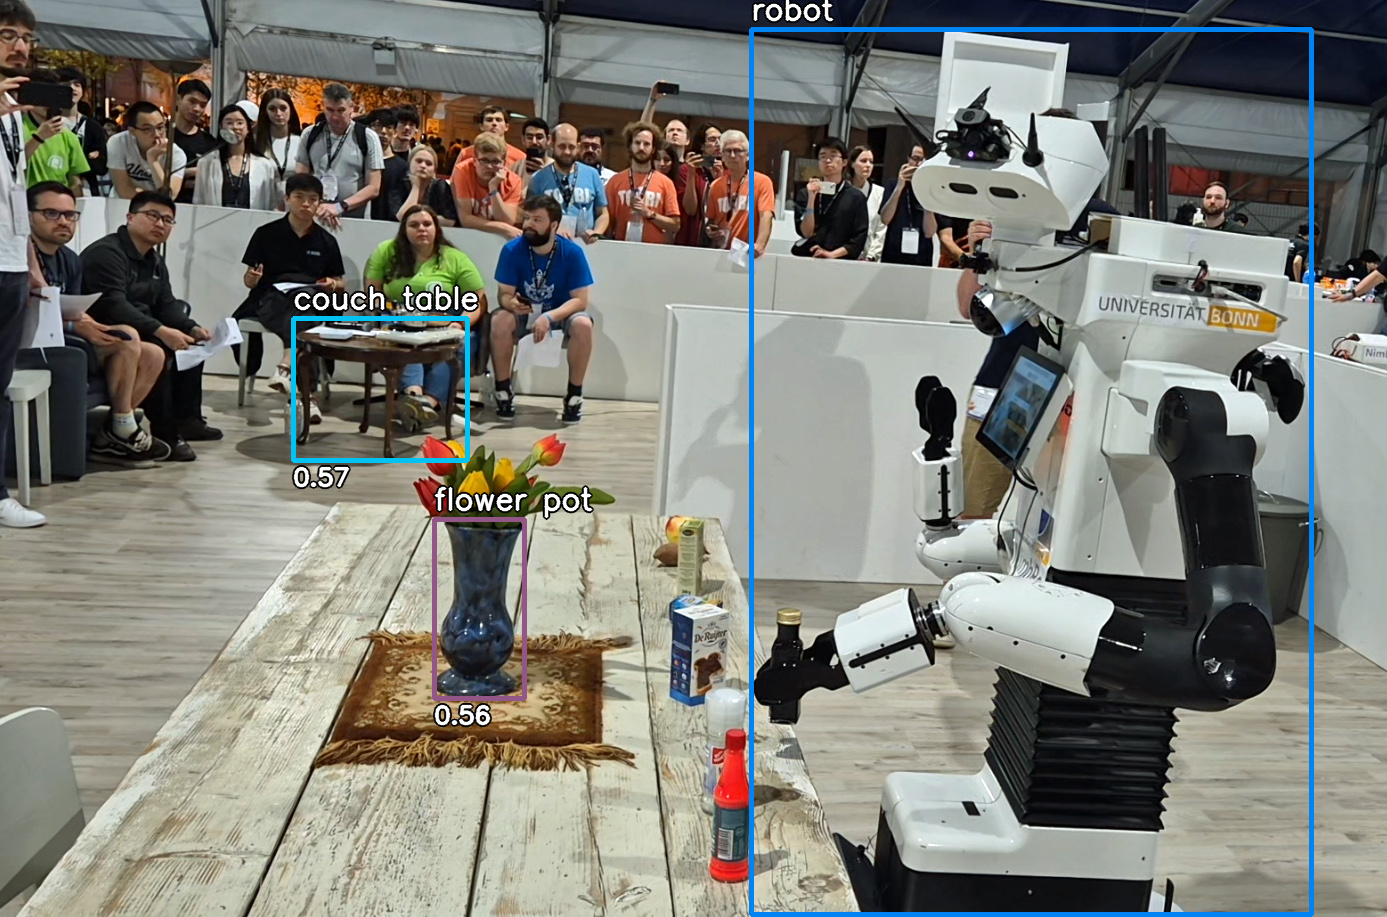

In [48]:
bboxes = [detection['box_xyxy'] for detection in detections]
confidences = [detection['confidence'] for detection in detections]
prompts = [detection['prompt'] for detection in detections]
show(visualize(image=img_np, bboxes=bboxes, labels=prompts, confidences=confidences, masks=None))

In [49]:
box_prompts = [{'object_id': idx, 'bbox': det['box_xyxy']} for idx, det in enumerate(detections)]
points_prompts = [
    {'object_id': 41, 'points': [[80,415], [120,460]], 'labels': [1, 0]},
    {'object_id': 42, 'points': [[560,215], [580,270]], 'labels': [1, 0]}
]
prompts = box_prompts# + points_prompts
print(prompts)

[{'object_id': 0, 'bbox': [293, 318, 467, 460]}, {'object_id': 1, 'bbox': [434, 519, 524, 698]}, {'object_id': 2, 'bbox': [751, 29, 1311, 914]}]


In [50]:
success, message, results = node.api_director.sam2_realtime_update(
    image=img_b64,
    prompts=prompts,
    model_id=0,
    model_flavor="large",
    retry=False
)

2025-06-18 14:34:13.566 [INFO] [nimbro_api_tutorial.api_director]: [sam2_realtime_update] Successfully retrieved 'sam2_realtime' update response after '0.231s'.


In [51]:
len(results)

3

In [52]:
results[0]

{'box_xyxy': [296, 332, 460, 460],
 'mask': 'iVBORw0KGgoAAAANSUhEUgAAAKQAAACACAAAAACg4529AAAEzklEQVR4Ac3BCYLbSBIEQff/PzqWdYEFdEvD5KGlmSyhkS8kQzjIt5EunMk3kS5cyBeRJvwg/yFs5JOkCb+Qvwi/kY+QJvyB/C78kbydNOFv5Cz8nbyZNOHN5J2kCZ8gLwrSSBM+RZ4RNiJd+Ch5TPiN0oV/QH4V/ot04Z+RJhRIF76ZdOGbSRO+mtyE7yY34bvJTfhqCoSvJgLhq4kQvpsI4csphC+nEL6bCOG7iRC+miCEP5Eh/B8JQvid/BT+PZHwk/xV+Awh/CASfpCHhbeRLlwp4QcpCRXyU5CTsFHCD1ITHiYPCRslXElReJA8KNyJhCspCo+RR4U7kXAlReEx8qiwUcKVFIXHyKNCY2iUcCVV4RHysHAjoVHClRSFh8jjIjehUcKVFIU7IfxKykKjhCspCot04RdSFholXElRmGQKP0hdaJRwJUVhkiVcSV1olHAlRWGSJVxJXWiUcCVFYZJDOJMnhEYJV1IUBrkLZ/KE0CjhSorCJIdwJk8IjRKupChMcghnUhc6DVdSFSY5hDOpC41IuJCqMMkhnMgTQiMSrqQoTHIIJ/KMcCNCuJCiMMkhnMhzAiKEM6kKg9yFE3mBEM6kKgxyF07kCZFOIJxIVRhkE3ZSF5BGIJxIVRhkE3ZSEzppBMKJVIVBNmEnNaGTRiCcSVEYZBM2UhQ6aeQmnEhRGGQTNlIUBrmRm3AiRWGQTdhITZjkRm7CTqrCIJuwkZowSCNN2EhVGGQTNlITBmmkCRspC53chZ3UhEEaacJGykIjm7CRojBII03YSF24kV24k6IwSCNN2MhzIrtwJ0VhkEaasJG3CHdSFAZppAt3UhZAzsJBqkInnQzhIFWhkZNwkKrQSSdTmKQsNLILd1IUBulkCp3UhU524U6KwiCdTKG

In [53]:
success, message, results = node.api_director.sam2_realtime_track(
    image=img_b64,
    model_id=0,
    retry=False
)

2025-06-18 14:34:16.750 [INFO] [nimbro_api_tutorial.api_director]: [sam2_realtime_track] Successfully retrieved 'sam2_realtime' inference response after '0.251s'.


In [54]:
len(results)

3

In [55]:
results[0]

{'box_xyxy': [296, 333, 463, 460],
 'mask': 'iVBORw0KGgoAAAANSUhEUgAAAKcAAAB/CAAAAACvEI1yAAAE1klEQVR4Ac3BAWKkOhIFwcz7H/ptIyEhbOYPZdOzHSG7MMgHkiacyYeRJnwlH0U24Tv5i7CSt5JNuCL/IVyRN5FN+AO5Fv5I3kE24T/JKvyVPE024Q3kQbIJbyI/F3YCsglvJCXhG0E24d3kr8KfKZvwr8gX4RbZhH/MUCOb8OlkEz6dvIRPp7yET6e8hE+nvIQPJ/ISPpwIhE8nAuHTiUD4dCKEjydC+Hgi4fOJhM8nEq7JFP7PRMIl+YPw74mES/Ifwr8lEq7IPeFfEAlX5L5QJbswyS58IxIuSEWokL8KZ2K4IhWhQO4IKzFckZJwl9wTViLhgpSEu+SmsBAJF6Qk3CR3hYMg4YKUhJvkvjAIEi5ISbhHCsIkEi5ISbhFKsIkEi5IRbhHKsIkEi5IRZjkJVySkjCJhAtSEQbpwgUpCZMYLkhJGGQXvpOSMInhgpSEQYbwjZSEQTBckJIwyBC+kpowCIYLUhIGmcIXUhMGwXBBSsIgU/hCasJOwHBBSsIgUziTorATkPCdlIRBpnAmRWEnIOE7KQmDTOFMisJOQMJ3UhIGmcKZFIVOXoTwjZSEnRzCmRSFTl6E8I2UhJ0cwpkUhU5ehPCN1IRODuFMakInG4HwldSERhbhRIpCJxuB8IUUhUYW4USKQicbgfCFFIVGFuFEikIjjbyEMykKjSzCiRSFRhp5CWdSFBpZhJUUhU4aeQlnUhQaWYSVFIVOGtmEEykKjSzCSopCJ41swkqqQiOLsJKa0Eknm7CSqrCRRTiRmtBJJ5uwkqqwkUU4kZKwk06asJCy8CKLsJKasJNOmnCQnwjIIqykJuykkyYcpCxsZBUWUhN20kkTDlIWNrIKCykKnXTShYNUhY2swkJui2xCI53swiRVYSOrsJDbAgKhkU5

In [56]:
prompts = [{'mask': result['mask'], 'bbox': result['box_xyxy']} for result in results]

In [57]:
success, message, results = node.api_director.dam(
    image=img_b64,
    prompts=prompts,
    query="Describe the masked region in detail.",
    model_flavor="3B",
    temperature=0.2,
    top_p=0.5,
    num_beams=1,
    max_new_tokens=512,
    max_batch_size=32,
    retry=False
)

2025-06-18 14:34:23.814 [INFO] [nimbro_api_tutorial.api_director]: [dam] Successfully retrieved 'dam' inference response after '3.545s'.


In [58]:
for i, result in enumerate(results):
    print(f"{i}: {result}")

0: A dark wooden table with a rectangular top and four elegantly curved legs. The legs are connected by a lower horizontal support beam, and the table has a slightly raised edge around the perimeter.
1: A tall, slender vase with a glossy, dark blue finish. The vase has a slightly flared rim and a bulbous base that tapers into a narrow neck. The surface features subtle, irregular patterns and a few reflective spots.
2: The robot is a white, articulated model with a humanoid shape, featuring a prominent head with a pair of black, circular eyes and a small, rectangular display screen. It has a black, cylindrical torso with a ribbed texture, and its arms are white with black joints. The right arm is extended outward, and the left arm is bent at the elbow. The robot's legs are black with a ribbed texture, and it has a black, rectangular base. The word "UNIVERSITY" is printed in black on the upper part of the torso, and there is a yellow and black label on the right side of the torso.


## Usage Monitoring

#### You can retrieve detailed logs of your usage.

In [59]:
node.api_director.get_usage()

2025-06-18 14:34:26.891 [INFO] [nimbro_api_tutorial.api_director]: Successfully retrieved usage in '0.000s'.


(True,
 "Successfully retrieved usage in '0.000s'.",
 {'completions': {'history': [{'stamp': '2025-06-18T14:32:57.486297',
     'api_endpoint': 'OpenAI',
     'model_name': 'gpt-4o',
     'tokens_input_uncached': 26,
     'tokens_output': 11,
     'dollars_input': 6.5e-05,
     'dollars_output': 0.00010999999999999999,
     'dollars_total': 0.00017499999999999997},
    {'stamp': '2025-06-18T14:33:00.639257',
     'api_endpoint': 'OpenAI',
     'model_name': 'gpt-4o',
     'tokens_input_uncached': 48,
     'tokens_output': 30,
     'dollars_input': 0.00012,
     'dollars_output': 0.00030000000000000003,
     'dollars_total': 0.00042},
    {'stamp': '2025-06-18T14:33:02.937463',
     'api_endpoint': 'OpenAI',
     'model_name': 'gpt-4o',
     'tokens_input_uncached': 96,
     'tokens_output': 30,
     'dollars_input': 0.00024,
     'dollars_output': 0.00030000000000000003,
     'dollars_total': 0.00054},
    {'stamp': '2025-06-18T14:33:16.391619',
     'api_endpoint': 'OpenAI',
     'mod

#### For example, you can get the total amount of dollars spent on the Completions API or all APIs. (Currently only the Completions and Embeddings APIs are supported).

In [60]:
node.api_director.get_usage()[2]['completions']['dollars_total']

0.006765

2025-06-18 14:34:30.955 [INFO] [nimbro_api_tutorial.api_director]: Successfully retrieved usage in '0.000s'.


In [61]:
node.api_director.get_usage()[2]['dollars_total']

2025-06-18 14:34:31.631 [INFO] [nimbro_api_tutorial.api_director]: Successfully retrieved usage in '0.000s'.


0.006765

#### By providing ISO timestamps, you can truncate the usage considered before a timestamp, after a timestamp, or both.

In [62]:
import datetime
stamp_iso_start = (datetime.datetime.now() - datetime.timedelta(minutes=5)).isoformat()
stamp_iso_end = (datetime.datetime.now() - datetime.timedelta(minutes=2)).isoformat()

In [63]:
node.api_director.get_usage(stamp_start=stamp_iso_start, stamp_end=stamp_iso_end)

2025-06-18 14:34:36.619 [INFO] [nimbro_api_tutorial.api_director]: Successfully retrieved usage in '0.000s'.


(True, "Successfully retrieved usage in '0.000s'.", {})